# 01 — Basic mock fit

**Goal:** generate a synthetic galaxy spectrum with a _known_ LOSVD, fit it with
`kinextract`, and verify that we recover the correct velocity and dispersion.

No external files are needed — everything is generated in this notebook.

---
## Method overview

1. Build a synthetic stellar template with CaII triplet absorption features.
2. Broaden and shift the template with a Gaussian LOSVD of known $V$ and $\sigma$.
3. Add Gaussian noise (S/N $\approx$ 50).
4. Write the spectrum and template to temporary files.
5. Configure and run `kinextract.run_spectral_fit`.
6. Compare the recovered LOSVD to the truth.

The Gaussian broadening is computed in pixel space (valid to ~1% over the
400 Å CaII fit window), using:

$$\sigma_\mathrm{pix} = \frac{\sigma_\mathrm{km/s} \cdot \lambda_\mathrm{center}}{c \cdot \Delta\lambda}$$

In [ ]:
from __future__ import annotations
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, shift as ndimage_shift

from kinextract import FitConfig, run_spectral_fit
from kinextract.losvd import fit_losvd_gauss_hermite

plt.style.use('kinextract.mplstyle')

print('kinextract imported OK')

## 1. Instrument and grid parameters

In [2]:
# MUSE-like CaII triplet setup
WAVEMIN    = 4750.0     # Å — full spectrum start
STEP       = 1.25       # Å — pixel size
N_PIX      = 3681       # pixels in full spectrum
WAVEFITMIN = 8400.0     # Å — fit range start
WAVEFITMAX = 8800.0     # Å — fit range end
LAM_CENTER = 8580.0     # Å — representative wavelength
CEE        = 299792.458 # km/s

wavelength = WAVEMIN + np.arange(N_PIX) * STEP
print(f'Wavelength range: {wavelength[0]:.1f} – {wavelength[-1]:.1f} Å  ({N_PIX} pixels)')

Wavelength range: 4750.0 – 9350.0 Å  (3681 pixels)


## 2. Build a synthetic template

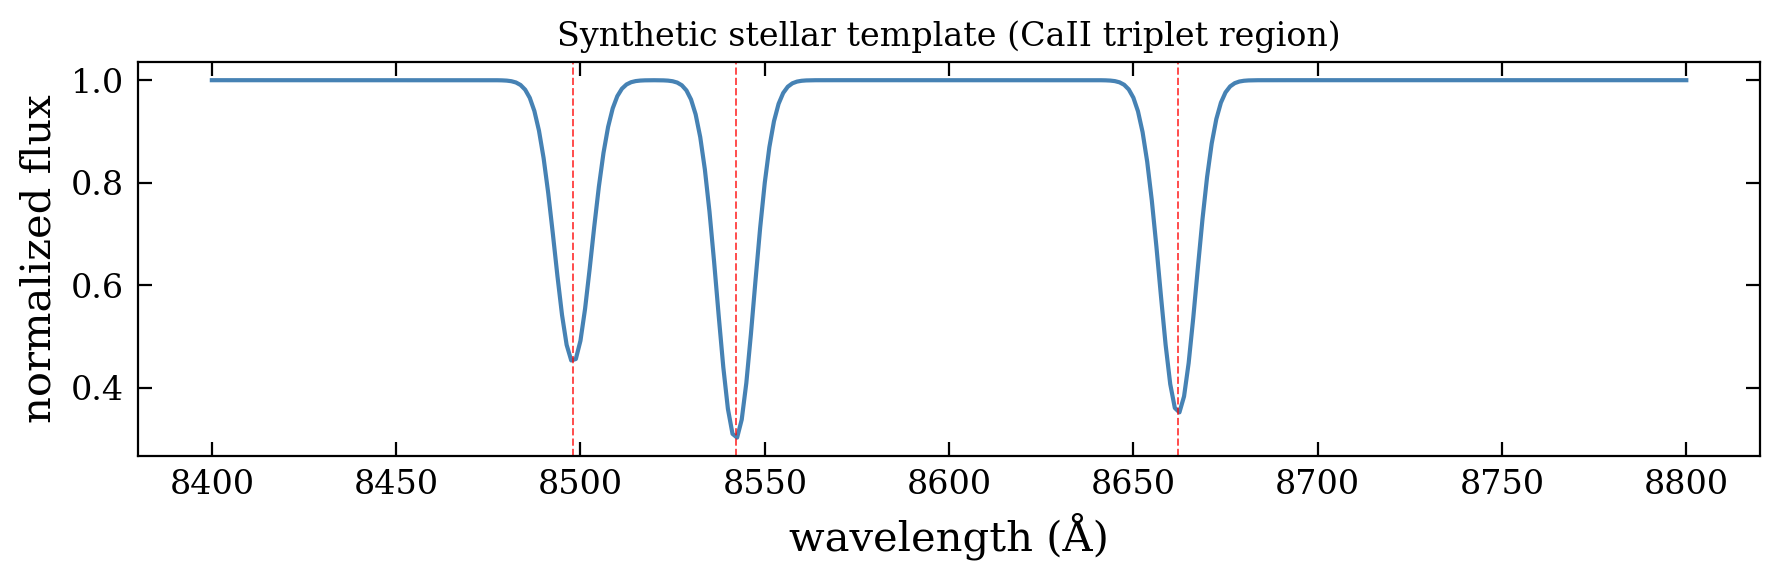

In [3]:
CA_CENTERS = [8498.02, 8542.09, 8662.14]
CA_DEPTHS  = [0.55, 0.70, 0.65]

template = np.ones(N_PIX)
for cen, depth in zip(CA_CENTERS, CA_DEPTHS):
    template -= depth * np.exp(-0.5 * ((wavelength - cen) / 5.0) ** 2)

# Show the template in the fit window
mask = (wavelength >= WAVEFITMIN) & (wavelength <= WAVEFITMAX)
plt.figure(figsize=(9, 3))
plt.plot(wavelength[mask], template[mask], lw=1.5, color='steelblue')
for c in CA_CENTERS:
    plt.axvline(c, lw=0.7, color='red', ls='--', alpha=0.7)
plt.xlabel('wavelength (Å)')
plt.ylabel('normalized flux')
plt.title('Synthetic stellar template (CaII triplet region)')
plt.tight_layout()
plt.show()

## 3. Apply a known LOSVD

We use a Gaussian LOSVD with:
- **$V$ = +80 km/s** (recession velocity relative to systemic)
- **$\sigma$ = 140 km/s** (velocity dispersion)

In [ ]:
TRUE_V     =  80.0  # km/s
TRUE_SIGMA = 140.0  # km/s

sigma_pix = TRUE_SIGMA * LAM_CENTER / (CEE * STEP)
shift_pix = TRUE_V    * LAM_CENTER / (CEE * STEP)
print(f'sigma_pix = {sigma_pix:.2f}   shift_pix = {shift_pix:.2f}')

broadened = gaussian_filter(template, sigma=sigma_pix)
galaxy    = ndimage_shift(broadened, shift=+shift_pix)  # + = redshift

# Add noise
RNG    = np.random.default_rng(42)
NOISE  = 0.02
galaxy = galaxy + RNG.normal(0.0, NOISE, N_PIX)
errors = np.full(N_PIX, NOISE)

# Preview template vs galaxy
plt.figure(figsize=(9, 3))
plt.plot(wavelength[mask], template[mask],    lw=1.2, color='steelblue', label='template (rest)')
plt.plot(wavelength[mask], galaxy[mask],      lw=1.2, color='tomato',    label=f'galaxy  V={TRUE_V}, ' + r'$\sigma$' + f'={TRUE_SIGMA} km/s', alpha=0.85)
plt.xlabel('wavelength (Å)')
plt.ylabel('normalized flux')
plt.title('Template vs synthetic galaxy spectrum')
plt.legend(fontsize=9, framealpha=1.0, facecolor='white').set_zorder(20)
plt.tight_layout()
plt.show()

## 4. Write files and create FitConfig

In [5]:
tmpdir    = Path(tempfile.mkdtemp(prefix='kinextract_nb01_'))
spec_path = tmpdir / 'mock_galaxy.spec'
tmpl_path = tmpdir / 'mock_template.dat'

np.savetxt(spec_path, np.column_stack([np.arange(1, N_PIX+1), galaxy, errors]),
           fmt='%6d  %14.8f  %14.8f')
np.savetxt(tmpl_path, np.column_stack([wavelength, template, np.full(N_PIX, 0.001)]),
           fmt='%10.4f  %14.8f  %12.8f')
(tmpdir / 'Tlist').write_text('mock_template.dat\n')

cfg = FitConfig(
    template_list_file  = str(tmpdir / 'Tlist'),
    template_dir        = str(tmpdir),
    outdir              = str(tmpdir),
    wavemin_full        = WAVEMIN,
    step                = STEP,
    wavefitmin          = WAVEFITMIN,
    wavefitmax          = WAVEFITMAX,
    zgal                = 0.0,
    fit_als_continuum   = False,
    xlam_auto           = True,
    xlam_auto_grid      = (10., 100., 1000., 10000., 100000.),
    xlam_smooth_threshold = 0.25,
    xlam_max_peaks      = 1,
    sigl                = 100.0,
    use_spectrum_errors = True,
    clean               = False,
    map_maxiter         = 5000,
    print_every         = 999999,
)
print('FitConfig created.')

FitConfig created.


## 5. Run the fit

In [6]:
fit = run_spectral_fit(cfg, gal_file=str(spec_path))

st  = fit['state']

b   = fit['outputs']['b']     # recovered LOSVD
gp  = fit['outputs']['gp']    # best-fit model spectrum
out = fit['outputs']
print(f"xlam chosen : {st.xlam:.0f}")
print(f"chi2_red    : {out['chi2_red']:.3f}  (target ≈ 1.0)")
print(f"ngood pixels: {fit['ngood']}")

[     1.17s] ==== spectral fitting START | /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_nb01_88s6rykh/mock_galaxy.spec ====
[     1.17s] wavefit=[8400.0, 8800.0] z=0.0 sigl=100.0 xlam=300.0
[     1.17s] fit_als_continuum=False prenorm=True
[     1.17s] START build FitState
[     1.17s] START read spectrum
[     1.18s] fit pixels=319 step=1.25
[     1.18s] END   read spectrum (0.00s)
[     1.18s] START apply masks
[     1.19s] END   apply masks (0.01s)
[     1.19s] START read + interpolate templates
[     1.19s] Template fractional error (pooled median): 0.0010
[     1.19s] END   read + interpolate templates (0.00s)
[     1.19s] LOSVD velocity grid from sigl: [-450.000, 450.000] km/s, nl=29
[     1.19s] nlosvd reference wavelength: 7048.7500
[     1.19s] START precompute LOSVD + ip map
[     1.19s] END   precompute LOSVD + ip map (0.00s)
[     1.19s] STATE: npix=319 nt=1 nl=29 nlosvd=34 prenormalized=False fit_als_continuum=False
[     1.19s] END   build FitState (0.02s)


## 6. Gauss-Hermite moments

In [7]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)

print('Recovered moments (from LOSVD via GH fit):')
print(f"  V     = {gh['vherm']:+.1f} km/s   (truth: +{TRUE_V:.0f} km/s)")
print(f"  sigma = {gh['sherm']:.1f} km/s   (truth:  {TRUE_SIGMA:.0f} km/s)")
print(f"  h3    = {gh['h3']:+.4f}")
print(f"  h4    = {gh['h4']:+.4f}")
print()
print(f"  ΔV    = {abs(gh['vherm'] - TRUE_V):.1f} km/s")
print(f"  Δσ    = {abs(gh['sherm'] - TRUE_SIGMA):.1f} km/s")

Recovered moments (from LOSVD via GH fit):
  V     = +80.1 km/s   (truth: +80 km/s)
  sigma = 135.7 km/s   (truth:  140 km/s)
  h3    = +0.0036
  h4    = +0.0065

  ΔV    = 0.1 km/s
  Δσ    = 4.3 km/s


## 7. Diagnostic plots

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('kinextract mock recovery', fontsize=13)

# --- spectral fit ---
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='steelblue', label='galaxy', alpha=0.8)
ax.plot(st.x, gp, lw=1.8, color='tomato',    label='model',  zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.3)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel('normalized flux')
ax.set_title(r'Spectral fit  $\chi^2_{\rm red}$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)

# --- LOSVD ---
ax = axes[1]
v_true = np.linspace(-450, 450, 29)
b_true = np.exp(-0.5 * ((v_true - TRUE_V) / TRUE_SIGMA) ** 2)
b_true /= np.trapezoid(b_true, v_true)
b_rec   = b / np.trapezoid(b, st.xl)

ax.plot(v_true, b_true, lw=2.0, color='grey',  ls='--', label='truth')
ax.plot(st.xl,  b_rec,  lw=2.0, color='tomato',         label='recovered')
ax.axvline(TRUE_V,      lw=0.8, color='grey',  ls=':')
ax.axvline(gh['vherm'], lw=0.8, color='tomato', ls=':')
ax.text(0.97, 0.03,
        f"truth:       V={TRUE_V:+.0f}  " + r"$\sigma$" + f"={TRUE_SIGMA:.0f} km/s\n"
        f"recovered:  V={gh['vherm']:+.0f}  " + r"$\sigma$" + f"={gh['sherm']:.0f} km/s",
        transform=ax.transAxes, fontsize=8, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))
ax.set_xlabel('velocity (km/s)')
ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title('Recovered vs true LOSVD')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(-500, 500)

plt.tight_layout()
plt.show()

## 8. Built-in diagnostic plots

The panels above were built by hand to show exactly what goes into them, but
`kinextract.plotting` ships ready-made versions of the same quick-look plots —
useful when you just want a fast look at a fit without writing any plotting code.

- `plot_fit(fit)` — data vs. model, with residuals
- `plot_losvd(fit)` — recovered LOSVD with its Gauss-Hermite overlay, plus template weights

(There's also `plot_als_continuum(fit, cfg)` for fits with `fit_als_continuum=True`,
including labeled absorption/emission features — see notebook 03 for that one,
since this notebook doesn't use the ALS continuum fitter.)

In [ ]:
from kinextract.plotting import plot_fit, plot_losvd

plot_fit(fit)
plot_losvd(fit)